In [7]:
import pandas as pd
import seaborn as sns

In [8]:
df = pd.read_csv(r"data\dataset_aula01_techshop_vendas (1).csv",
parse_dates =["data_pedido"])

In [9]:
df["faturamento"] = df["preco_unitario"] * df ["quantidade"]
df.head()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento
0,2024-01-01,Acessórios,36.20,1,Sudeste,Instagram,3.3,36.20
1,2024-01-01,Acessórios,122.61,5,Sudeste,Orgânico,4.4,613.05
2,2024-01-02,Acessórios,151.19,4,Sul,Google Ads,4.6,604.76
3,2024-01-03,TVs,3399.16,2,Sudeste,Google Ads,4.1,6798.32
4,2024-01-04,Smartphones,3180.94,2,Nordeste,Instagram,3.9,6361.88


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   data_pedido      800 non-null    datetime64[ns]
 1   categoria        800 non-null    object        
 2   preco_unitario   800 non-null    float64       
 3   quantidade       800 non-null    int64         
 4   regiao           800 non-null    object        
 5   canal_marketing  800 non-null    object        
 6   avaliacao        800 non-null    float64       
 7   faturamento      800 non-null    float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(3)
memory usage: 50.1+ KB


In [11]:
df_tratado = df.copy()

In [12]:
df_tratado["faturamento"] = df_tratado["preco_unitario"] * df_tratado["quantidade"]

In [13]:
df_tratado.head()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento
0,2024-01-01,Acessórios,36.20,1,Sudeste,Instagram,3.3,36.20
1,2024-01-01,Acessórios,122.61,5,Sudeste,Orgânico,4.4,613.05
2,2024-01-02,Acessórios,151.19,4,Sul,Google Ads,4.6,604.76
3,2024-01-03,TVs,3399.16,2,Sudeste,Google Ads,4.1,6798.32
4,2024-01-04,Smartphones,3180.94,2,Nordeste,Instagram,3.9,6361.88


In [14]:
df_tratado["faturamento"].sum()

np.float64(2847624.13)

In [15]:
print(df_tratado["faturamento"].sum())

2847624.13


In [16]:
#colocar numa variavel
faturamento_total = df_tratado["faturamento"].sum()
print(faturamento_total)

2847624.13


In [18]:
#melhorar o numero de cima ai / troca primeiro para o x para dps o . pq ja tem um . e daria um bug
#Realizando a conversão de USD para REAL
faturamento_correto = f"{faturamento_total: ,.2f}".replace(",", "x").replace(".",",").replace("x",".")
faturamento_correto

' 2.847.624,13'

In [19]:
df_tratado.head()

,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento
0,2024-01-01,Acessórios,36.20,1,Sudeste,Instagram,3.3,36.20
1,2024-01-01,Acessórios,122.61,5,Sudeste,Orgânico,4.4,613.05
2,2024-01-02,Acessórios,151.19,4,Sul,Google Ads,4.6,604.76
3,2024-01-03,TVs,3399.16,2,Sudeste,Google Ads,4.1,6798.32
4,2024-01-04,Smartphones,3180.94,2,Nordeste,Instagram,3.9,6361.88


In [20]:
# groupby Agrupa os bagulho cara
df_tratado.groupby("categoria")["faturamento"].sum()

categoria
Acessórios     103851.41
Notebooks      922453.90
Smartphones    970236.71
TVs            463526.50
Áudio          387555.61
Name: faturamento, dtype: float64

In [21]:
#agrupamento, agrupa 2 colunas e extrai as informaçoes/ groupby Agrupa os bagulho cara o sort_values esta colocando em ordem do menor ao maior
df_tratado.groupby("categoria")["faturamento"].sum().sort_values()

categoria
Acessórios     103851.41
Áudio          387555.61
TVs            463526.50
Notebooks      922453.90
Smartphones    970236.71
Name: faturamento, dtype: float64

In [22]:
#por regiao
df_tratado.groupby("regiao")["faturamento"].sum().sort_values()

regiao
Norte            188452.12
Centro-Oeste     313101.36
Sul              509659.07
Nordeste         548131.32
Sudeste         1288280.26
Name: faturamento, dtype: float64

In [23]:
#(ascending=False) ele mostra a ascendencia e nos conseguimos colocar do maior ao menor ou menor ao maior
df_tratado.groupby("regiao")["faturamento"].sum().sort_values(ascending=False)

regiao
Sudeste         1288280.26
Nordeste         548131.32
Sul              509659.07
Centro-Oeste     313101.36
Norte            188452.12
Name: faturamento, dtype: float64

In [24]:
df_tratado.loc[799,"canal_marketing"]

'Google Ads'

In [25]:
def converter(valor):
    return f"R$ {valor:,.2f}".replace(",", "x").replace(".",",").replace("x",".")

In [26]:
agrupamento_faturamentoRegiao = df_tratado.groupby("regiao")["faturamento"].sum().sort_values()
agrupamento_faturamentoRegiao.map(converter)

regiao
Norte             R$ 188.452,12
Centro-Oeste      R$ 313.101,36
Sul               R$ 509.659,07
Nordeste          R$ 548.131,32
Sudeste         R$ 1.288.280,26
Name: faturamento, dtype: object

## continuarção aula04

Text(0.5, 1.0, 'Contagem por categoria')

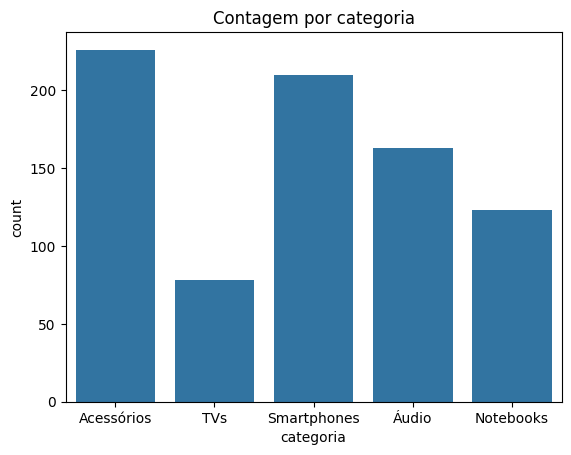

In [27]:
grafico = sns.countplot(data=df,x="categoria")
grafico.set_title("Contagem por categoria")


Text(0.5, 0, 'Categorias')

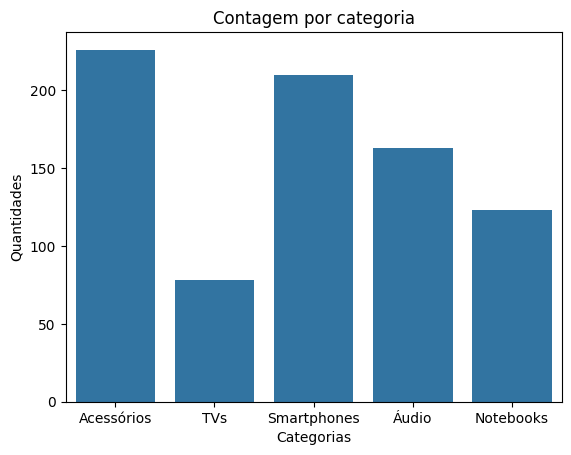

In [28]:
grafico = sns.countplot(data=df,x="categoria")
grafico.set_title("Contagem por categoria")
grafico.set_ylabel("Quantidades")
grafico.set_xlabel("Categorias")

In [29]:
df.groupby("categorias")[df]

KeyError: 'categorias'

Text(0.5, 0, 'Categorias')

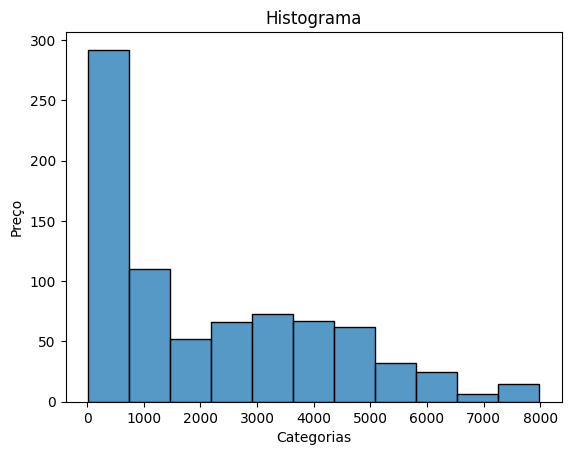

In [ ]:
grafico = sns.histplot(data=df,x = "preco_unitario")
grafico.set_title("Histograma")
grafico.set_ylabel("Preço")
grafico.set_xlabel("Categorias")

Text(0.5, 1.0, 'Histograma')

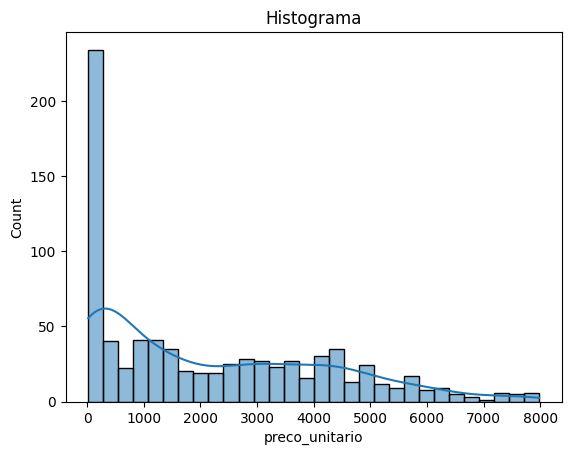

In [ ]:
grafico = sns.histplot(data=df,x = "preco_unitario",kde=True,bins=30)
grafico.set_title("Histograma")

Text(0.5, 0, 'Categorias')

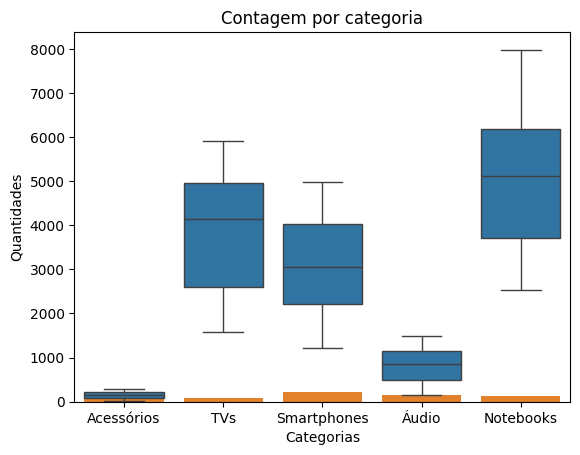

In [ ]:
grafico = sns.boxplot(data=df,x="categoria",y="preco_unitario")
grafico = sns.countplot(data=df,x="categoria")
grafico.set_title("Contagem por categoria")
grafico.set_ylabel("Quantidades")
grafico.set_xlabel("Categorias")


In [ ]:
df = df_tratado.copy()
df.head()


,data_pedido,categoria,preco_unitario,quantidade,regiao,canal_marketing,avaliacao,faturamento,faturametno
0,2024-01-01,Acessórios,36.20,1,Sudeste,Instagram,3.3,36.20,36.20
1,2024-01-01,Acessórios,122.61,5,Sudeste,Orgânico,4.4,613.05,613.05
2,2024-01-02,Acessórios,151.19,4,Sul,Google Ads,4.6,604.76,604.76
3,2024-01-03,TVs,3399.16,2,Sudeste,Google Ads,4.1,6798.32,6798.32
4,2024-01-04,Smartphones,3180.94,2,Nordeste,Instagram,3.9,6361.88,6361.88


In [ ]:
df.to_csv("dataset_tratado.cvc")